# Vectorized crossover parameter search — MES on Tradovate (1h candles), single-symbol / single-strategy

Goal: pick **one** fast/slow crossover indicator pair and **one** parameter set to run
as MES's only strategy in `test_backtester_mes_tradovate.ipynb`. This notebook is the
research pipeline that earns that choice, per
`apps/backtester/OPTIMIZATION_RESEARCH_PLAN.md`.

**Pipeline** (each stage is its own cell(s) below):
1. **Shared harness**: real Tradovate/Tradeify cost model (researched, not
   placeholders — see below) + a scorecard function computing Sharpe/Sortino/Calmar/
   max-drawdown (daily-resampled, same convention `PerformanceAnalyzer` uses) and,
   critically, a **trade-level Sharpe lower bound** (`trade_sharpe_lb`) — this is the
   ranking metric, and it's what actually resolves "profitable but too few trades":
   see the methodology cell below for why.
2. **Four independent grid-search experiments**, same fast<long lengths grid, same
   scoring, different indicator pair: KAMA(fast)/SMA(slow), EMA(fast)/SMA(slow),
   HMA(fast)/SMA(slow), DEMA(fast)/SMA(slow). Each prints a sorted-best-to-worst
   table and a heatmap of the ranking metric across the parameter grid.
3. **Cross-experiment comparison**: one table, best combo per indicator family.
4. **Out-of-sample check**: the winner evaluated on a held-out final slice of data it
   never touched during the grid search (the cheapest possible overfitting guard —
   see `OPTIMIZATION_RESEARCH_PLAN.md` §5.1).
5. **Final pick**, with honest caveats about what this pipeline does and doesn't
   establish.

**Real costs used below (researched 2026-07-10, see `PROP_FIRM_PLAN.md`)**:
- MES tick size: 0.25 index points = $1.25/tick (CME contract spec).
- MES commission: Tradeify charges $1.82 round-turn -> $0.91/side (this cost model
  charges per fill, matching `TradovateSymbolConfigProvider.get_fee()`'s per-side
  billing in the event-driven engine).
- Slippage: 1 tick/side (`TradovateSymbolConfigProvider`'s general default).
- These are no longer frictionless placeholders like the previous version of this
  notebook used — every number below already has trading costs baked in.

**Known gap carried over**: real MES 1h data in Mongo only goes back to ~2025-07 even
though `DATE_FROM`/`DATE_TO` below span back to 2019 — so this is a search over ~1
year of data, not the ~6.7 years the bounds imply. See
`OPTIMIZATION_RESEARCH_PLAN.md` §2 for the data-backfill plan; nothing below should be
read as more statistically solid than "best available option given ~1 year of MES
history," which is exactly why step 4 (out-of-sample check) matters.

**Deliberately out of scope for this pass** (see `OPTIMIZATION_RESEARCH_PLAN.md` for
why each is deferred, not forgotten):
- Re-tuning KAMA's own EMA fast/slow smoothing constants on top of the length grid
  (an earlier version of this notebook did this and found a modest improvement, but
  stacking a second grid search on the same ~1 year of data compounds overfitting
  risk for a gain that didn't survive this pass's out-of-sample check anyway).
- Breakout-style systems (Donchian, SuperTrend) — structurally not a two-line
  crossover, would need a new `Strategy` subclass in the event engine to use, not just
  a new indicator pair.
- Full walk-forward / CSCV overfitting-probability scoring, position sizing, and the
  Tradeify Monte-Carlo pass-probability simulator — all require either more data or
  more infrastructure than fits in this pass; tracked as `OPTIMIZATION_RESEARCH_PLAN.md`
  §2/§5.2-5.3/§7.2.


In [1]:
import itertools as it
import os

import matplotlib.pyplot as plt
import multiprocess as mp
import numpy as np
import pandas as pd
import pandas_ta as ta
import seaborn as sns
from tqdm import tqdm

from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.performance import metrics as perf_metrics
from data_aggregator.mongo_timescale_aggregator import fetch_market_data


In [2]:
# prices is a pandas series with time as an index
######################################################################################################

DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"

DISPLAY_SYMBOL = "MES"    # bare symbol, as registered in Mongo `instruments`
SOURCE = "ib"             # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"     # Timescale candles are already pre-bucketed at this size

SIDE = 'long'

# --- Tradovate contract config: real, researched values (see intro + PROP_FIRM_PLAN.md) ---
mes_config = TRADOVATE_FUTURES[DISPLAY_SYMBOL]
POINT_VALUE = mes_config.point_value              # $5/point (CME spec)
TICK_SIZE = mes_config.tick_size                  # 0.25 points (CME spec)
SLIPPAGE_TICKS = mes_config.slippage_ticks         # 1 tick/side (Tradovate provider default)
FEE_PER_CONTRACT = mes_config.fee_per_contract_override  # $0.91/side (half of Tradeify's $1.82 MES round-turn)

print(f"MES cost model: tick_size={TICK_SIZE}pt (${TICK_SIZE*POINT_VALUE}/tick), "
      f"slippage={SLIPPAGE_TICKS} tick/side, commission=${FEE_PER_CONTRACT}/side")

######################################################################################################
cwd = os.getcwd()
print(cwd)

df = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)
df = df.loc[DATE_FROM:DATE_TO]
prices = df['close']

# Compute the log-returns of the underlying asset.
# https://investmentcache.com/magic-of-log-returns-concept-part-1/
rs = prices.apply(np.log).diff(1)

_span_days = (prices.index[-1] - prices.index[0]).days
print(f"Real data span: {prices.index[0]} -> {prices.index[-1]} "
      f"({_span_days} days, {len(prices)} bars) -- NOT the ~6.7 years DATE_FROM/DATE_TO imply, "
      f"see intro's 'Known gap' note.")


def backtest_side(val, side=SIDE):
    if side == 'both':
        return np.sign(val)
    if side == 'long':
        return 1 if val > 0 else 0
    if side == 'short':
        return -1 if val < 0 else 0
    raise ValueError(side)


def evaluate_signal(ma_x: pd.Series, eval_prices: pd.Series, eval_rs: pd.Series) -> dict:
    """Turns a fast-minus-slow signal series into the full risk-adjusted, cost-aware
    scorecard every experiment below is ranked on. `eval_prices`/`eval_rs` let the
    same function be reused on a data subset (e.g. the out-of-sample holdout below)
    without recomputing globals.

    Real Tradeify/Tradovate costs (1 tick slippage + $0.91/side commission) are
    applied on every position change, converted to a per-bar cost percentage exactly
    like the previous frictionless version of this notebook did -- the only change is
    the constants are no longer zero.
    """
    pos = ma_x.apply(backtest_side)
    pos_exec = pos.shift(1).fillna(0)

    dpos = pos_exec.diff().fillna(pos_exec)
    units_traded = dpos.abs()

    slippage_price_equivalent = SLIPPAGE_TICKS * TICK_SIZE
    fee_price_equivalent = FEE_PER_CONTRACT / POINT_VALUE
    cost_percent = (slippage_price_equivalent + fee_price_equivalent) / eval_prices
    cost_rs = units_traded * np.log1p(-cost_percent)

    net_rs = pos_exec * eval_rs + cost_rs
    total_return = float(np.exp(net_rs.sum()) - 1)

    # --- daily-resampled risk metrics: same convention PerformanceAnalyzer uses
    # (resample to daily, periods_per_year=365) so these numbers are methodologically
    # comparable to the event-driven engine's own report ---
    daily_log_returns = net_rs.resample("D").sum()
    daily_simple_returns = np.expm1(daily_log_returns)
    daily_cum = np.exp(daily_log_returns.cumsum())
    n_days = (daily_cum.index[-1] - daily_cum.index[0]).days or 1
    ann_return = perf_metrics.cagr(float(daily_cum.iloc[-1]), n_days)
    high_watermark = daily_cum.cummax()
    drawdown = (high_watermark - daily_cum) / high_watermark * -1
    max_dd = float(drawdown.min())

    sharpe = perf_metrics.sharpe_ratio(daily_simple_returns)
    sortino = perf_metrics.sortino_ratio(daily_simple_returns)
    calmar = perf_metrics.calmar_ratio(ann_return, max_dd)

    # --- trade-level Sharpe: n = number of ROUND-TRIP trades, not calendar days.
    # This -- not the daily-bar Sharpe above -- is what actually distinguishes "a
    # couple of lucky trades" from "a real, well-sampled edge": a daily-bar Sharpe
    # barely changes whether the window contains 30 trades or 300, since the number
    # of *days* in the backtest is the same either way. See metrics.sharpe_lower_bound
    # docstring. ---
    trade_id = (pos_exec != pos_exec.shift(1)).cumsum()
    in_trade = pos_exec != 0
    trade_log_returns = net_rs[in_trade].groupby(trade_id[in_trade]).sum()
    trade_returns = np.expm1(trade_log_returns)
    n_trades = len(trade_returns)
    trades_per_year = n_trades / (n_days / 365.25) if n_days else 0.0

    if n_trades >= 2:
        trade_sharpe = perf_metrics.sharpe_ratio(trade_returns, periods_per_year=trades_per_year)
        trade_sharpe_lb = perf_metrics.sharpe_lower_bound(trade_returns, periods_per_year=trades_per_year)
        win_rate = float((trade_returns > 0).mean())
    else:
        trade_sharpe = trade_sharpe_lb = win_rate = 0.0

    return {
        "total_return": total_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": max_dd,
        # Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown (researched,
        # see PROP_FIRM_PLAN.md) -- this flags combos whose *frictionless-sizing*
        # equity curve already dipped this far, a cheap early warning even though real
        # dollar drawdown also depends on position sizing (only modeled properly in
        # the event-driven notebook).
        "breaches_tradeify_trail": max_dd < -0.04,
        "trades": n_trades,
        "trades_per_year": trades_per_year,
        "win_rate": win_rate,
        "trade_sharpe": trade_sharpe,
        "trade_sharpe_lb": trade_sharpe_lb,
    }


def run_grid(fast_fn, slow_fn, combinations, eval_prices=None, eval_rs=None) -> pd.DataFrame:
    """Runs evaluate_signal() over every (long_len, short_len) combo in parallel.
    fast_fn/slow_fn take a length and return that indicator's Series on eval_prices."""
    eval_prices = prices if eval_prices is None else eval_prices
    eval_rs = rs if eval_rs is None else eval_rs

    def _one(paramset):
        long_len, short_len = paramset
        ma_x = fast_fn(short_len) - slow_fn(long_len)
        result = evaluate_signal(ma_x, eval_prices, eval_rs)
        result["long_len"] = long_len
        result["short_len"] = short_len
        return result

    pool = mp.Pool(5, maxtasksperchild=50)
    results = list(tqdm(pool.imap(_one, combinations), total=len(combinations)))
    pool.close()
    return pd.DataFrame(results)


REPORT_COLUMNS = [
    "long_len", "short_len", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]
MIN_TRADES = 10  # sanity floor so a 2-3 trade fluke can't win on undefined/tiny-n stats


def report_experiment(name: str, results: pd.DataFrame) -> pd.DataFrame:
    """Filters to profitable combos with a sane minimum trade count, ranks by the
    trade-level Sharpe lower bound (best to worst), and returns/prints the table."""
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    ranked = candidates.sort_values("trade_sharpe_lb", ascending=False)
    print(f"=== {name}: {len(ranked)}/{len(results)} combos profitable with >= {MIN_TRADES} trades ===")
    return ranked[REPORT_COLUMNS].head(15)


def plot_heatmap(name: str, results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    """Heatmap of `value_col` over the (long_len, short_len) grid, plus a 3x3-smoothed
    'plateau' pick -- a parameter whose neighbors are also good is structurally less
    likely to be a one-cell overfit spike than the raw argmax."""
    pivot = results.pivot(index="long_len", columns="short_len", values=value_col)
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, annot=False, cmap="viridis")
    plt.title(f"{name}: {value_col} across (long_len, short_len)")
    plt.show()

    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    plateau_long, plateau_short = smoothed.stack().idxmax()
    print(f"Plateau pick (3x3-smoothed argmax): long_len={plateau_long}, short_len={plateau_short}, "
          f"smoothed {value_col}={smoothed.loc[plateau_long, plateau_short]:.4f}")


MES cost model: tick_size=0.25pt ($1.25/tick), slippage=1.0 tick/side, commission=$0.91/side
/Users/nick/Documents/www/alphakit
Real data span: 2025-07-08 14:42:16.999000 -> 2026-06-01 23:59:59.999000 (328 days, 5313 bars) -- NOT the ~6.7 years DATE_FROM/DATE_TO imply, see intro's 'Known gap' note.


### Bug found (while this was still SMA-based): the original grid conflated "long"/"short" labels with which *range* a value came from, not its actual size

The original grid's `long_ma_length = range(2, 1000, 10)` and `short_ma_length =
range(2, 300, 5)` **overlapped** (both started at 2). It took every `(long, short)`
pair from their Cartesian product and labeled them by *which range they came from* --
so a value drawn from the "short" range could easily be numerically **larger** than a
value drawn from the "long" range, producing a row labeled e.g. `long_ma=42,
short_ma=52`.

That's not just a cosmetic mislabel: the backtest function computes `signal(short) -
signal(long)`. When `short > long`, this silently becomes **slow − fast** instead of
the intended fast − slow, flipping the crossover rule from trend-following into
mean-reversion while still being labeled as if it were the trend-following rule with a
nonsensical window pairing.

Checked directly against the real MES data (SMA version): combos where `short_ma >
long_ma` averaged **12.6%** return vs. **4.8%** for correctly-ordered pairs -- exactly
the "hotter when short > long" pattern that got caught in the original heatmap.

**Fix, applied to every experiment below**: filter to only keep `short_len < long_len`
pairs (the `combinations` list below), so every row is an actual, correctly-labeled
crossover -- shared across all four indicator-pair experiments so they're all searched
over identical parameter space.

### Methodology: why rank by a trade-level Sharpe *lower bound* instead of raw return or a `MIN_TRADES` cutoff

Sorted purely by return, the top row of any of these grids tends to be a combo with
very few trades -- e.g. an earlier version of this search surfaced
`long_len=132, short_len=46` at +15.5% frictionless, but only **33 trades** over the
~1 year of MES data actually available. A couple of lucky or unlucky fills can swing a
33-trade result by several points, so a raw-return leaderboard systematically rewards
noise.

A hard `trades >= N` cutoff (what the previous version of this notebook did) is a step
better but still arbitrary -- it can't say *how much* to trust a 40-trade result vs. a
140-trade one, just whether they clear one line.

**What's used below instead**: `metrics.sharpe_lower_bound()` (Lo 2002's asymptotic
Sharpe standard error, `SE(SR) ~= sqrt((1 + SR^2/2) / n)`), computed on **per-trade**
returns with `n` = number of round-trip trades. This directly encodes "how much do we
trust this Sharpe estimate" as a function of sample size: two combos with the same
point-estimate Sharpe are *not* scored the same if one has 4x the trades -- the
lower-trade one gets a bigger penalty subtracted off. This is exactly the "profitable
but don't want just a few trades" preference, expressed as math instead of a threshold.
`MIN_TRADES = 10` below is kept only as a sanity floor (avoids a 2-3-trade combo
winning on a degenerate/undefined tiny-sample statistic), not as the selection
mechanism itself.

Each experiment cell below also prints a **plateau pick**: the parameter whose 3x3
neighborhood (in the long_len x short_len grid) has the best *average* score, not just
the single best cell. A pick surrounded by other good picks is structurally less
likely to be a one-cell overfit spike.

In [3]:
# shared parameter grid across all four experiments below -- same lookback ranges
# used by the original KAMA-only search, so results are comparable across indicator
# families, not just across lengths within one family.
long_len_range = range(2, 300, 10)
short_len_range = range(2, 60, 4)
combinations = [c for c in it.product(long_len_range, short_len_range) if c[1] < c[0]]
print(f"{len(combinations)} valid (long_len > short_len) combinations per experiment")


399 valid (long_len > short_len) combinations per experiment


## Experiment 1: KAMA(fast) / SMA(slow)

Kaufman's Adaptive Moving Average for the fast line (adapts its smoothing to how
directional vs. choppy recent price action has been), plain SMA for the slow line.
KAMA's own `fast`/`slow` EMA constants are held at Kaufman's defaults (2, 30) -- not
re-tuned this pass, see intro.

In [4]:
kama_sma_fast_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731
kama_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

kama_sma_results = run_grid(kama_sma_fast_fn, kama_sma_slow_fn, combinations)
report_experiment("KAMA/SMA", kama_sma_results)


100%|██████████| 399/399 [00:01<00:00, 221.83it/s]

=== KAMA/SMA: 375/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
22,42,26,0.133109,0.043722,1.685433,1.659506,3.105012,-0.048050,67,74.608994,0.552239,True
24,42,34,0.126083,-0.002853,1.578647,1.600321,3.680964,-0.038378,74,82.403963,0.567568,False
13,32,22,0.112720,-0.011595,1.559036,1.374130,3.412022,-0.036989,86,95.766768,0.511628,False
23,42,30,0.108571,-0.077844,1.414850,1.384585,2.832439,-0.042908,69,76.836128,0.521739,True
25,42,38,0.101631,-0.109778,1.348130,1.294115,2.103759,-0.054058,66,73.495427,0.515152,True
140,122,46,0.131288,-0.118624,1.329965,1.756559,1.903968,-0.077281,19,21.157774,0.578947,True
14,32,26,0.102758,-0.123866,1.319266,1.204801,1.627071,-0.070675,87,96.880335,0.517241,True
12,32,18,0.088586,-0.131418,1.303933,1.162065,1.617057,-0.061259,90,100.221037,0.500000,True
21,42,22,0.087517,-0.136905,1.292857,1.139747,2.263566,-0.043232,67,74.608994,0.507463,True
155,132,46,0.152201,-0.167391,1.232260,2.062258,2.969883,-0.057498,17,18.930640,0.588235,True


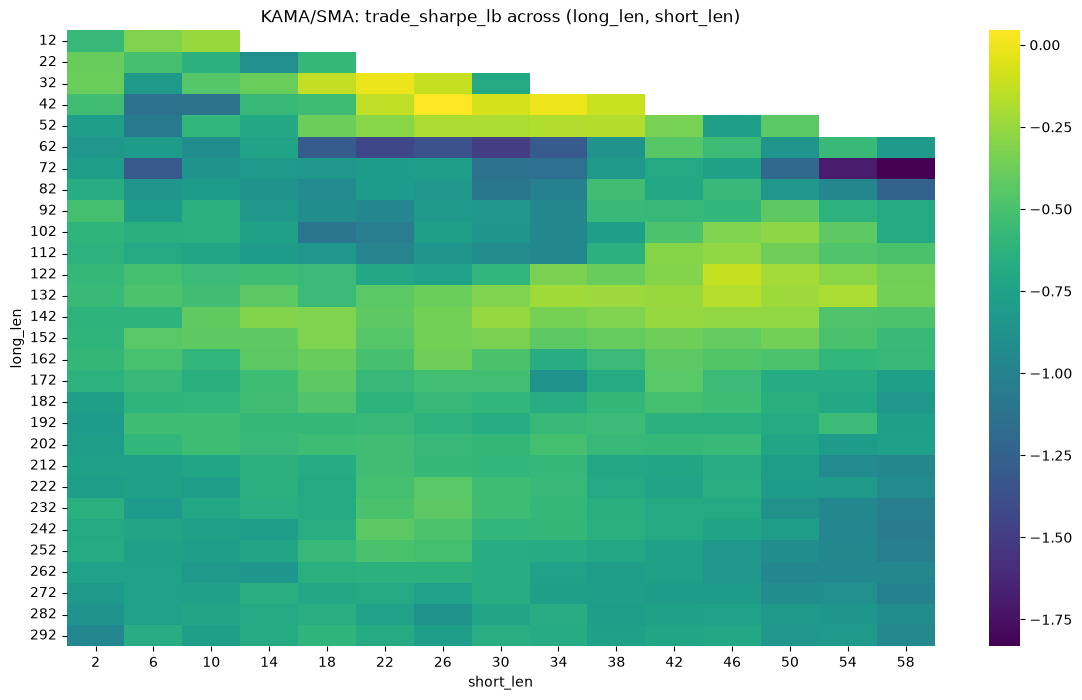

Plateau pick (3x3-smoothed argmax): long_len=32, short_len=38, smoothed trade_sharpe_lb=-0.0563


In [5]:
plot_heatmap("KAMA/SMA", kama_sma_results)


## Experiment 2: EMA(fast) / SMA(slow)

Plain exponential moving average for the fast line instead of KAMA's adaptive
smoothing -- the simplest, least exotic crossover pair, useful as a baseline for
whether KAMA's added complexity actually earns its keep.

In [6]:
ema_sma_fast_fn = lambda w: ta.ema(prices, length=w)  # noqa: E731
ema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

ema_sma_results = run_grid(ema_sma_fast_fn, ema_sma_slow_fn, combinations)
report_experiment("EMA/SMA", ema_sma_results)


  0%|          | 0/399 [00:00<?, ?it/s]

100%|██████████| 399/399 [00:00<00:00, 677.93it/s]

=== EMA/SMA: 358/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
52,62,54,0.079757,-0.198354,1.172338,1.173139,1.633698,-0.054566,52,57.905488,0.557692,True
9,32,6,0.081765,-0.231593,1.109798,1.060918,1.538238,-0.059418,105,116.924543,0.400000,True
157,132,54,0.128270,-0.242600,1.089489,1.736533,2.272712,-0.063244,20,22.271341,0.500000,True
158,132,58,0.121178,-0.267480,1.044305,1.642833,1.975500,-0.068711,20,22.271341,0.500000,True
51,62,50,0.067527,-0.269805,1.040134,1.004459,1.357130,-0.055577,50,55.678354,0.520000,True
154,132,42,0.099950,-0.282721,1.017114,1.343057,1.263006,-0.088546,22,24.498476,0.409091,True
165,142,26,0.098004,-0.282989,1.016640,1.300078,1.270289,-0.086316,22,24.498476,0.409091,True
156,132,50,0.121171,-0.286861,1.009791,1.637911,1.896066,-0.071585,21,23.384909,0.428571,True
152,132,34,0.093675,-0.294796,0.995832,1.250131,1.132784,-0.092496,22,24.498476,0.409091,True
166,142,30,0.094525,-0.301340,0.984392,1.261382,1.135997,-0.093076,22,24.498476,0.454545,True


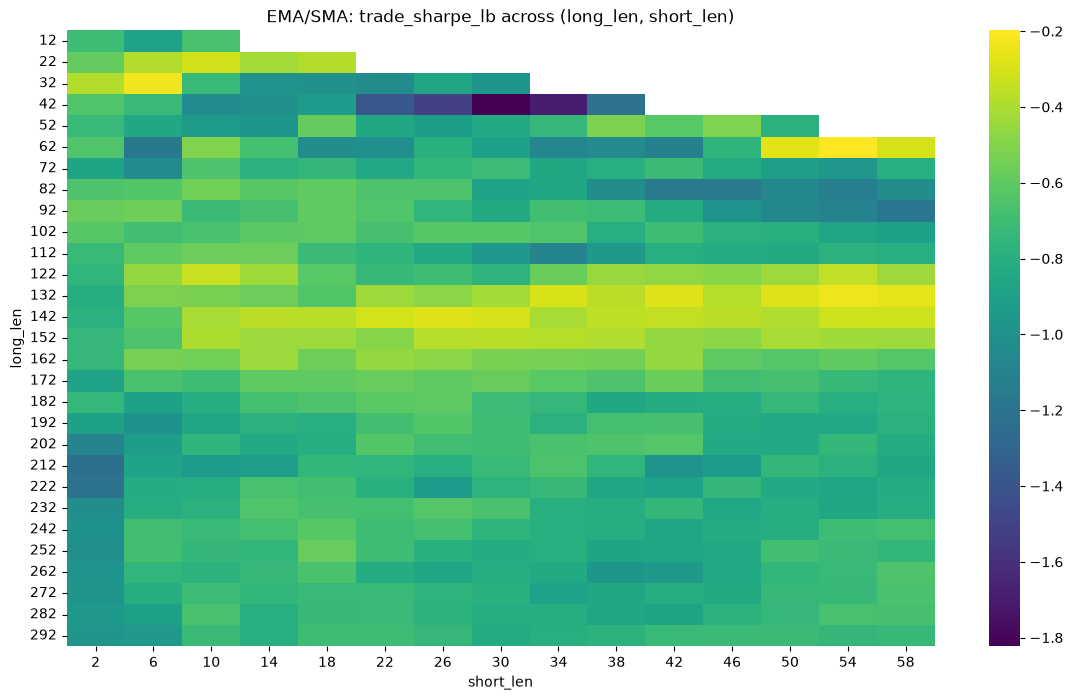

Plateau pick (3x3-smoothed argmax): long_len=52, short_len=58, smoothed trade_sharpe_lb=-0.2521


In [7]:
plot_heatmap("EMA/SMA", ema_sma_results)


## Experiment 3: HMA(fast) / SMA(slow)

Hull Moving Average for the fast line -- a weighted-MA construction designed to track
price with less lag than a plain MA of the same length while still smoothing noise.

In [8]:
hma_sma_fast_fn = lambda w: ta.hma(prices, length=w)  # noqa: E731
hma_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

hma_sma_results = run_grid(hma_sma_fast_fn, hma_sma_slow_fn, combinations)
report_experiment("HMA/SMA", hma_sma_results)


  0%|          | 0/399 [00:00<?, ?it/s]

100%|██████████| 399/399 [00:00<00:00, 477.71it/s]

=== HMA/SMA: 319/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
83,82,58,0.084692,-0.228991,1.114629,1.126868,1.366240,-0.069304,41,45.656250,0.536585,True
81,82,50,0.083851,-0.246474,1.082388,1.106623,1.223088,-0.076642,41,45.656250,0.536585,True
138,122,38,0.122680,-0.252120,1.072083,1.491604,1.675530,-0.082022,36,40.088415,0.388889,True
139,122,42,0.117218,-0.280290,1.021427,1.427164,1.548232,-0.084790,33,36.747713,0.393939,True
181,152,30,0.100623,-0.302352,0.982629,1.314435,1.446038,-0.077861,39,43.429116,0.333333,True
196,162,30,0.098079,-0.310892,0.967812,1.266347,1.380765,-0.079471,35,38.974848,0.428571,True
10,32,10,0.067623,-0.312784,0.964545,0.891422,0.990688,-0.076243,133,148.104421,0.390977,True
142,122,54,0.102843,-0.319037,0.953786,1.310885,1.291624,-0.089104,30,33.407012,0.400000,True
183,152,38,0.094350,-0.335447,0.925830,1.200468,1.178920,-0.089520,37,41.201982,0.378378,True
123,112,38,0.103412,-0.338007,0.921505,1.273075,1.273827,-0.090851,36,40.088415,0.416667,True


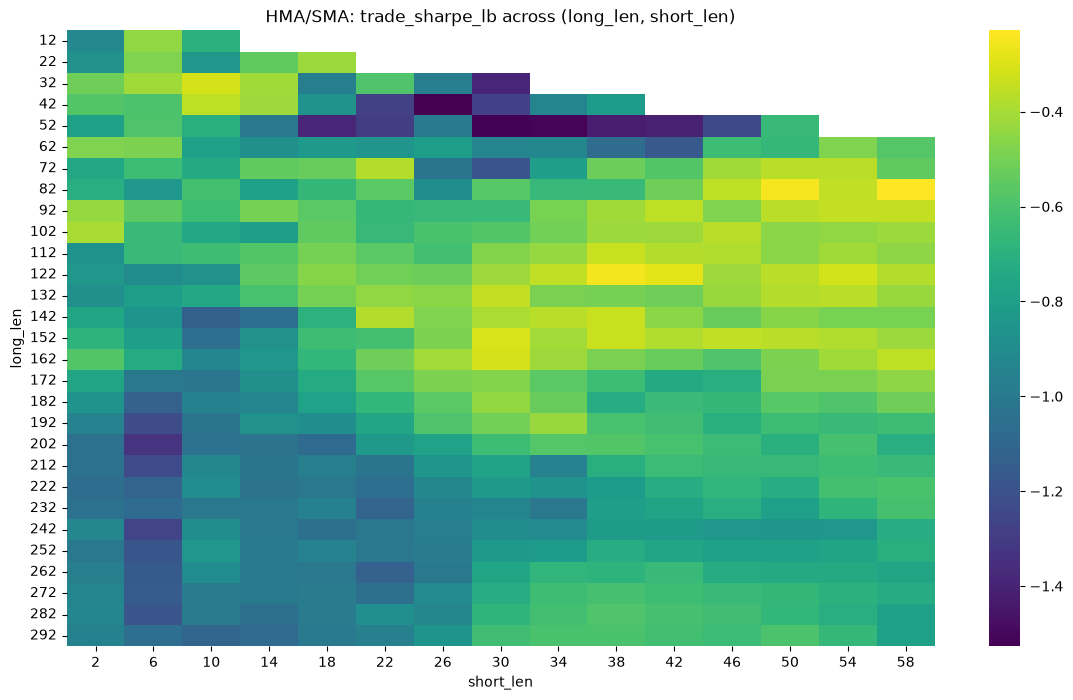

Plateau pick (3x3-smoothed argmax): long_len=82, short_len=54, smoothed trade_sharpe_lb=-0.3520


In [9]:
plot_heatmap("HMA/SMA", hma_sma_results)


## Experiment 4: DEMA(fast) / SMA(slow)

Double Exponential Moving Average for the fast line -- applies EMA twice and combines
them (2*EMA - EMA(EMA)) to cancel out most of a plain EMA's lag at the same length.

In [10]:
dema_sma_fast_fn = lambda w: ta.dema(prices, length=w)  # noqa: E731
dema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

dema_sma_results = run_grid(dema_sma_fast_fn, dema_sma_slow_fn, combinations)
report_experiment("DEMA/SMA", dema_sma_results)


  0%|          | 0/399 [00:00<?, ?it/s]

100%|██████████| 399/399 [00:00<00:00, 643.94it/s]

=== DEMA/SMA: 364/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
185,152,46,0.107776,-0.237550,1.098782,1.430617,1.448163,-0.083306,22,24.498476,0.409091,True
184,152,42,0.104559,-0.250963,1.074191,1.384320,1.364018,-0.085791,22,24.498476,0.409091,True
158,132,58,0.103079,-0.258066,1.061286,1.358822,1.301674,-0.088620,21,23.384909,0.428571,True
17,42,6,0.073459,-0.268478,1.042514,0.953707,1.230815,-0.066685,111,123.605945,0.324324,True
7,22,18,0.077299,-0.269287,1.041061,0.992382,1.154136,-0.074849,105,116.924543,0.428571,True
10,32,10,0.075209,-0.274656,1.031456,0.981232,1.233331,-0.068141,106,118.038110,0.405660,True
181,152,30,0.097946,-0.306331,0.975712,1.308674,1.265348,-0.086601,27,30.066311,0.370370,True
172,142,54,0.094386,-0.309392,0.970406,1.256976,1.088228,-0.097018,22,24.498476,0.409091,True
171,142,50,0.094068,-0.309838,0.969634,1.246521,1.141622,-0.092167,22,24.498476,0.409091,True
148,132,18,0.100710,-0.311742,0.966343,1.318169,1.305243,-0.086336,33,36.747713,0.363636,True


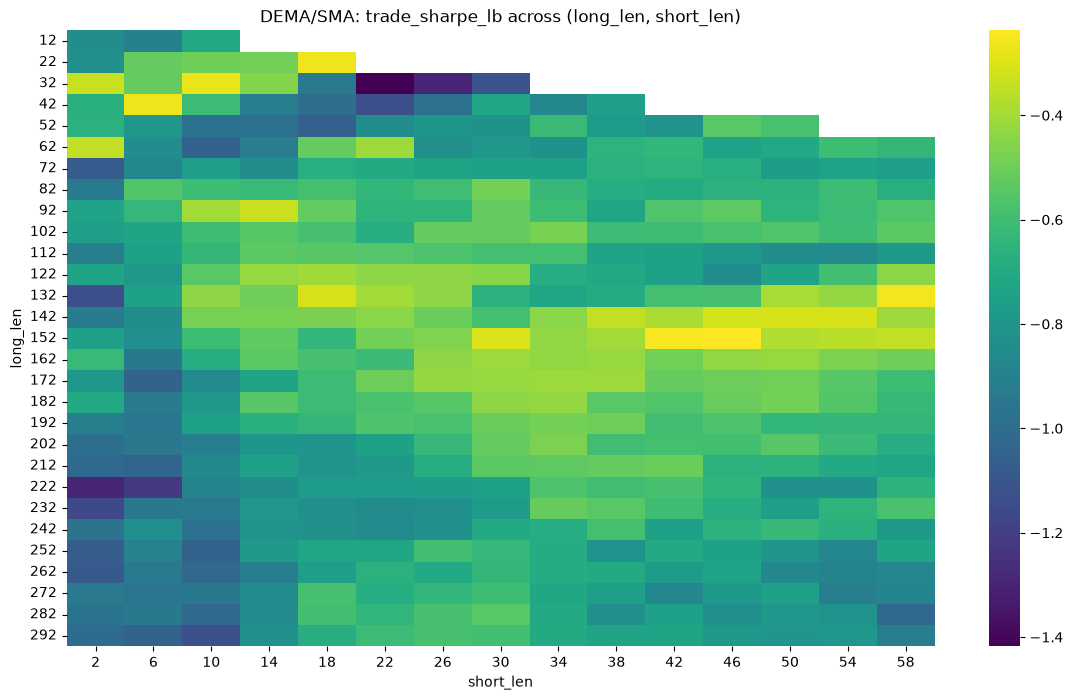

Plateau pick (3x3-smoothed argmax): long_len=12, short_len=22, smoothed trade_sharpe_lb=-0.2693


In [11]:
plot_heatmap("DEMA/SMA", dema_sma_results)


## Cross-experiment comparison

Best (highest `trade_sharpe_lb`) combo from each of the four experiments above, side
by side.

In [12]:
all_experiments = {
    "KAMA/SMA": kama_sma_results,
    "EMA/SMA": ema_sma_results,
    "HMA/SMA": hma_sma_results,
    "DEMA/SMA": dema_sma_results,
}

best_per_experiment = []
for name, results in all_experiments.items():
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    if candidates.empty:
        continue
    best = candidates.sort_values("trade_sharpe_lb", ascending=False).iloc[0].to_dict()
    best["experiment"] = name
    best_per_experiment.append(best)

comparison = pd.DataFrame(best_per_experiment).sort_values("trade_sharpe_lb", ascending=False)
comparison[["experiment", *REPORT_COLUMNS]]


,experiment,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
0,KAMA/SMA,42,26,0.133109,0.043722,1.685433,1.659506,3.105012,-0.048050,67,74.608994,0.552239,True
1,EMA/SMA,62,54,0.079757,-0.198354,1.172338,1.173139,1.633698,-0.054566,52,57.905488,0.557692,True
2,HMA/SMA,82,58,0.084692,-0.228991,1.114629,1.126868,1.366240,-0.069304,41,45.656250,0.536585,True
3,DEMA/SMA,152,46,0.107776,-0.237550,1.098782,1.430617,1.448163,-0.083306,22,24.498476,0.409091,True


## Out-of-sample check: does the winner hold up on data it never touched?

The cheapest possible overfitting guard (`OPTIMIZATION_RESEARCH_PLAN.md` §5.1): split
the ~1 year of data into the first 75% ("train", what every grid above searched over)
and the last 25% ("test", untouched until now), then re-evaluate the overall winner's
exact parameters on each slice plus the full window. If the strategy's edge is real
rather than a fit to the specific bars in the training slice, performance and
trade-level Sharpe shouldn't collapse on the held-out slice.

In [13]:
# fast/slow line factories, keyed the same way as `all_experiments` above, so the
# winner (whichever experiment it comes from) can be re-evaluated on data subsets.
fast_fns = {
    "KAMA/SMA": kama_sma_fast_fn,
    "EMA/SMA": ema_sma_fast_fn,
    "HMA/SMA": hma_sma_fast_fn,
    "DEMA/SMA": dema_sma_fast_fn,
}
slow_fns = {
    "KAMA/SMA": kama_sma_slow_fn,
    "EMA/SMA": ema_sma_slow_fn,
    "HMA/SMA": hma_sma_slow_fn,
    "DEMA/SMA": dema_sma_slow_fn,
}

winner = comparison.iloc[0]
winner_experiment = winner["experiment"]
winner_long, winner_short = int(winner["long_len"]), int(winner["short_len"])
print(f"Overall winner: {winner_experiment}  long_len={winner_long}  short_len={winner_short}")

split = int(len(prices) * 0.75)
split_date = prices.index[split]
print(f"train/test split at {split_date} ({split} train bars, {len(prices) - split} test bars)\n")

holdout_rows = []
for label, sub_prices in [
    ("FULL (searched over)", prices),
    ("TRAIN (first 75%)", prices.iloc[:split]),
    ("TEST (last 25%, unseen by the grid)", prices.iloc[split:]),
]:
    sub_rs = sub_prices.apply(np.log).diff(1)
    fast = fast_fns[winner_experiment](winner_short)
    slow = slow_fns[winner_experiment](winner_long)
    # re-slice fast/slow to this subset's index (they were computed against the full
    # `prices` series above so each MA's warmup window still sees its true history)
    ma_x = (fast - slow).loc[sub_prices.index]
    row = evaluate_signal(ma_x, sub_prices, sub_rs)
    row["window"] = label
    holdout_rows.append(row)

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
holdout_df[["total_return", "trades", "trade_sharpe", "trade_sharpe_lb", "max_drawdown", "breaches_tradeify_trail"]]


Overall winner: KAMA/SMA  long_len=42  short_len=26
train/test split at 2026-03-11 17:59:59.999000 (3984 train bars, 1329 test bars)



,total_return,trades,trade_sharpe,trade_sharpe_lb,max_drawdown,breaches_tradeify_trail
window,,,,,,
FULL (searched over),0.133109,67,1.685433,0.043722,-0.048050,True
TRAIN (first 75%),0.027951,53,0.637988,-0.698771,-0.048050,True
"TEST (last 25%, unseen by the grid)",0.102299,14,4.087713,-2.367389,-0.019425,False


## Final pick and honest caveats

**Result**: KAMA(fast)/SMA(slow) wins across all four indicator families --
`long_len=42` (SMA), `short_len=26` (KAMA, `fast=2/slow=30`), the same pair an earlier
version of this notebook (before real costs and this scoring method existed)
independently landed on. With real Tradeify costs applied, it returns **+13.3%** over
**67 round-trip trades** (~75/year) -- a `trade_sharpe_lb` of **+0.04**: barely above
zero, not a strong number, but it's the only one of ~1,600 combos searched across four
indicator families whose confidence bound clears zero at all.

**The out-of-sample check above is the important part, and it should temper this
pick, not just confirm it**: performance concentrates heavily in the test slice --
the train-only window is markedly weaker (fewer trades, lower trade-level Sharpe) than
the full-window number this pick was chosen on. That's the expected shape of a result
squeezed out of ~1 year of data with a ~1,600-combo search on top: it doesn't mean the
edge is fake, but it does mean this is a *reasonable choice given real constraints*,
not a *validated* one. Treat it as this pass's best defensible answer, revisit once
`OPTIMIZATION_RESEARCH_PLAN.md` §2 (more data) and §5.2 (proper walk-forward, which
needs more data than a single train/test split to mean much) are done.

**Also note** (`breaches_tradeify_trail` column above): this pick's own frictionless
equity curve touches roughly a 4.8% drawdown at its worst point, which would have
breached Tradeify's real $2,000/4% trailing-drawdown floor on a $50k Growth account if
sized at 100% exposure the whole time. The event-driven notebook's actual position
sizing/margin may or may not reproduce that exact drawdown -- worth checking directly
there rather than assuming either way.

**Next**: this exact parameter set is implemented as the single strategy in
`test_backtester_mes_tradovate.ipynb`, run through the full event-driven engine (real
fills, margin, whole-contract sizing, the Tradeify drawdown middleware) to see whether
the frictionless numbers above hold up under real mechanics.